# Defence Variant — Combined Median/MAD + Historical Cosine

This notebook combines the two defence mechanisms tested in Files 05G and 05H:

1. **Median/MAD magnitude defence** to detect unusually large or abnormal scalar update behaviour.
2. **Historical cosine defence with warm-up** to detect abnormal directional changes relative to each client's own previous-round behaviour.

The experiment keeps the same base setting:
- MNIST
- extreme non-IID, one label per client
- 3-layer model
- FL versus corrected SFL
- realistic SGA poisoning attack
- separate SFL client-side and server-side aggregators



# FL vs SFL — Non-IID One-Label-per-Client, 3-Layer Model

This notebook compares **Federated Learning (FL)** and **Split Federated Learning (SFL / Design 1)** on MNIST under an extreme non-IID setting.

**Non-IID setup:** each client receives data from only one label. With MNIST, this notebook uses **10 clients** so that labels 0–9 are all represented.

The model architecture is now a 3-layer MLP:

```text
Full FL model: 784 -> 256 -> 128 -> 10
SFL client:    784 -> 256
SFL server:    256 -> 128 -> 10
```

So the SFL client has **1 trainable layer**, and the SFL server has **2 trainable layers**. The FL-only model also has the same 3 trainable layers for every client.

After every global aggregation round, the notebook evaluates the global model on the full MNIST test set and stores one accuracy value per round for FL and SFL.


**Updated version:** corrected separate SFL aggregators plus realistic SGA poisoning attack on client 0 with no-NaN controls and annotated diagnostics.

In [1]:
NOTEBOOK_ID = "05I_combined_median_cosine"

import os

# --------------------------------------------------
# Project/output folders
# --------------------------------------------------
# This notebook is normally run from the notebooks/ folder.
# If the current working directory is notebooks/, outputs are saved one level above it:
#     project_root/results/...
#     project_root/weights/...
# If the notebook is run from the project root instead, outputs are saved in that project root.
CURRENT_DIR = os.path.abspath(os.getcwd())
if os.path.basename(CURRENT_DIR).lower() == "notebooks":
    PROJECT_ROOT = os.path.dirname(CURRENT_DIR)
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = os.path.join(PROJECT_ROOT, "data")

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
CSV_DIR = os.path.join(RESULTS_DIR, "csv", NOTEBOOK_ID)
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots", NOTEBOOK_ID)

WEIGHTS_DIR = os.path.join(PROJECT_ROOT, "weights", NOTEBOOK_ID)
FL_WEIGHTS_DIR = os.path.join(WEIGHTS_DIR, "fl")
SFL_WEIGHTS_DIR = os.path.join(WEIGHTS_DIR, "sfl")

# In the corrected SFL structure, there are two separate aggregation domains:
#   1) client-side FL aggregation for the client-owned layer(s)
#   2) SFL server-side aggregation for the server-owned layer(s)
# The reconstructed full SFL model is saved only for evaluation/plotting, not as a deployed global model.
SFL_CLIENT_FL_WEIGHTS_DIR = os.path.join(SFL_WEIGHTS_DIR, "client_side_fl_aggregator")
SFL_SERVER_WEIGHTS_DIR = os.path.join(SFL_WEIGHTS_DIR, "sfl_server_aggregator")
SFL_EVAL_WEIGHTS_DIR = os.path.join(SFL_WEIGHTS_DIR, "evaluation_reconstructed_only")

for folder in [
    DATA_DIR,
    CSV_DIR,
    PLOTS_DIR,
    FL_WEIGHTS_DIR,
    SFL_CLIENT_FL_WEIGHTS_DIR,
    SFL_SERVER_WEIGHTS_DIR,
    SFL_EVAL_WEIGHTS_DIR,
]:
    os.makedirs(folder, exist_ok=True)

print("CURRENT_DIR:", CURRENT_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CSV_DIR:", CSV_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("FL_WEIGHTS_DIR:", FL_WEIGHTS_DIR)
print("SFL_WEIGHTS_DIR:", SFL_WEIGHTS_DIR)
print("SFL_CLIENT_FL_WEIGHTS_DIR:", SFL_CLIENT_FL_WEIGHTS_DIR)
print("SFL_SERVER_WEIGHTS_DIR:", SFL_SERVER_WEIGHTS_DIR)
print("SFL_EVAL_WEIGHTS_DIR:", SFL_EVAL_WEIGHTS_DIR)



CURRENT_DIR: /home/raed/Documents/Masters_project_SFL_servers/notebooks
PROJECT_ROOT: /home/raed/Documents/Masters_project_SFL_servers
DATA_DIR: /home/raed/Documents/Masters_project_SFL_servers/data
CSV_DIR: /home/raed/Documents/Masters_project_SFL_servers/results/csv/05I_combined_median_cosine
PLOTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05I_combined_median_cosine
FL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05I_combined_median_cosine/fl
SFL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05I_combined_median_cosine/sfl
SFL_CLIENT_FL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05I_combined_median_cosine/sfl/client_side_fl_aggregator
SFL_SERVER_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05I_combined_median_cosine/sfl/sfl_server_aggregator
SFL_EVAL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05I_combined_median_cosine/sfl/evaluation

## Updated model used in this version

This notebook now uses a split-compatible **3-layer MLP**:

```text
Full FL model: 784 -> 256 -> 128 -> 10
SFL client:    784 -> 256
SFL server:    256 -> 128 -> 10
```

This gives exactly what we want for the SFL structure:

- **Client side:** 1 trainable layer
- **Server side:** 2 trainable layers
- **FL model:** same complete 3-layer model on every client

The split happens after the first hidden layer. The client produces the cut-layer activation of size 256, then the server completes the remaining two layers.


## Learning-rate update

This version uses the 3-layer architecture and the corrected separated SFL aggregation structure:

```text
Full model:   784 -> 256 -> 128 -> 10
SFL client:   784 -> 256
SFL server:   256 -> 128 -> 10
```

The notebook uses a round-level learning rate schedule with initial learning rate 0.04:

```python
INITIAL_LR = 0.04
LR_DECAY = 1.0
current_lr = INITIAL_LR * LR_DECAY ** (round_id - 1)
```

There is still no gradient clipping, no momentum, no BatchNorm, and no Adam. This keeps the FL/SFL equivalence check cleaner.


Corrected SFL aggregation structure:

```text
Client-side layer(s): aggregated by the client-side FL aggregator
Server-side layer(s): aggregated by the SFL server aggregator
Reconstructed full model: used only for evaluation/plotting
```


## Diagnostic note: why the one-label non-IID accuracy may not improve

This notebook uses the most extreme label-skew setting: **10 clients and each client receives only one MNIST class**.

That means:

- client 0 only trains on digit 0
- client 1 only trains on digit 1
- ...
- client 9 only trains on digit 9

Although all labels exist globally, each local optimisation step is based on only one class. This can cause **client drift**: each client update strongly pushes the model toward its own class. When FedAvg averages these highly biased updates, the global model may remain close to random guessing, especially with a deeper model, small number of rounds, and conservative learning-rate decay.

Notebook 02 may behave differently because it uses a different FL implementation/model structure and different hyperparameters. In particular, notebook 02 uses a simpler `TwoNN` model and may use different learning rate, local epochs, and experiment settings. Notebook 05 is stricter because it is trying to make FL and SFL mathematically equivalent, so it uses the same starting model, deterministic client loaders, and compares FL and SFL global states using L2 distance.


In [2]:
import os
import copy
import time
import random
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

## 1. Reproducibility and device setup

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Experiment settings and output folders

Run this notebook from the repository root folder: `Masters_project_SFL_servers/`.

In [4]:
# MNIST has 10 labels, so using 10 clients gives one label per client and still covers all classes.
NUM_CLIENTS = 10
ROUNDS = 100
LOCAL_EPOCHS = 1
BATCH_SIZE = 64
TEST_BATCH_SIZE = 256

# Set to an integer such as 1000 for a quick test run.
# Set to None for the full one-label-per-client dataset.
MAX_SAMPLES_PER_CLIENT = None

print("CSV results will be saved to:", CSV_DIR)
print("Plots will be saved to:", PLOTS_DIR)
print("Weights will be saved to:", WEIGHTS_DIR)

# --------------------------------------------------
# Learning rate
# --------------------------------------------------
# Mild round-level LR decay for the 784 -> 512 -> 256 -> 10 architecture.
# INITIAL_LR and LR_DECAY are defined only once in this notebook.
# The decay is applied once per communication round in the main training loop.
INITIAL_LR = 0.04
LR_DECAY = 0.99

def get_round_lr(round_id):
    """
    Return the learning rate for the current communication round.

    Example:
        round 1   -> 0.040000
        round 100 -> 0.04 * (0.99 ** 99)
    """
    return INITIAL_LR * (LR_DECAY ** (round_id - 1))


# --------------------------------------------------
# Realistic SGA poisoning attack configuration
# --------------------------------------------------
# Client 0 is the malicious client in both FL and SFL experiments.
# In FL, client 0 applies SGA to the full model.
# In SFL, client 0 reverses only the gradient returned to the client-side layer.
ENABLE_SGA_ATTACK = True
MALICIOUS_CLIENT_ID = 0

# The FL attack scale is deliberately small because FL client 0 controls the full model.
# A larger value can make the FL weights become inf/NaN in the first round.
ATTACK_SCALE_FL = 0.01

# The SFL attack scale applies only to the gradient returned to the client-side partition.
# This keeps the attack realistic: the SFL server-side update remains normal SGD.
ATTACK_SCALE_SFL = 20.0

# Gradient clipping keeps the poisoning experiment numerically stable.
# It does not remove the attack; it prevents exploding gradients from turning weights into inf/NaN.
ENABLE_GRAD_CLIPPING = False
MAX_GRAD_NORM = 20.0


CSV results will be saved to: /home/raed/Documents/Masters_project_SFL_servers/results/csv/05I_combined_median_cosine
Plots will be saved to: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05I_combined_median_cosine
Weights will be saved to: /home/raed/Documents/Masters_project_SFL_servers/weights/05I_combined_median_cosine


In [5]:
# ==================================================
# Combined Median/MAD + Historical Cosine defence with warm-up
# ==================================================
# This notebook combines:
#   1) Median/MAD magnitude-style filtering
#   2) True historical cosine direction filtering
#
# The historical cosine branch starts after a warm-up period because early-round
# benign updates are naturally noisy in the one-label-per-client non-IID setting.
DEFENCE_START_ROUND = 10

# Defence variant label used in logs and CSV files.
COMBINED_DEFENCE_MODE = "median_mad_plus_historical_cosine_warmup"

# A client is removed if EITHER median/MAD OR cosine flags it.
# This is stricter and is the recommended combined defence for this experiment.
COMBINED_FLAG_MODE = "union"

print("Using combined defence mode:", COMBINED_DEFENCE_MODE)
print("Combined flag mode:", COMBINED_FLAG_MODE)
print("Cosine warm-up rounds:", DEFENCE_START_ROUND)



Using combined defence mode: median_mad_plus_historical_cosine_warmup
Combined flag mode: union
Cosine warm-up rounds: 10


## 3. Load MNIST dataset

In [6]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 60000
Test samples: 10000


## 4. Create non-IID client datasets

Each client receives samples from only one label.

Example: client 1 gets label 0, client 2 gets label 1, ..., client 10 gets label 9.

In [7]:
def get_targets(dataset):
    if hasattr(dataset, "targets"):
        targets = dataset.targets
        if torch.is_tensor(targets):
            targets = targets.cpu().numpy()
        return np.array(targets)
    return np.array([dataset[i][1] for i in range(len(dataset))])


def create_one_label_client_subsets(dataset, num_clients: int, seed: int, max_samples_per_client=None):
    targets = get_targets(dataset)
    unique_labels = sorted(np.unique(targets).tolist())

    if num_clients > len(unique_labels):
        raise ValueError("num_clients cannot be greater than the number of labels for one-label-per-client setup.")

    selected_labels = unique_labels[:num_clients]
    rng = np.random.default_rng(seed)

    subsets = []
    client_label_map = {}

    for client_id, label in enumerate(selected_labels):
        label_indices = np.where(targets == label)[0]
        rng.shuffle(label_indices)

        if max_samples_per_client is not None:
            label_indices = label_indices[:max_samples_per_client]

        subsets.append(Subset(dataset, label_indices.tolist()))
        client_label_map[client_id] = label

    return subsets, client_label_map


client_subsets, client_label_map = create_one_label_client_subsets(
    train_dataset,
    num_clients=NUM_CLIENTS,
    seed=SEED,
    max_samples_per_client=MAX_SAMPLES_PER_CLIENT,
)

for client_id, subset in enumerate(client_subsets):
    print(f"Client {client_id + 1}: label={client_label_map[client_id]}, samples={len(subset)}")

sample_counts = [len(subset) for subset in client_subsets]
print("Total samples used:", sum(sample_counts))

Client 1: label=0, samples=5923
Client 2: label=1, samples=6742
Client 3: label=2, samples=5958
Client 4: label=3, samples=6131
Client 5: label=4, samples=5842
Client 6: label=5, samples=5421
Client 7: label=6, samples=5918
Client 8: label=7, samples=6265
Client 9: label=8, samples=5851
Client 10: label=9, samples=5949
Total samples used: 60000


## 5. Data loaders

FL and SFL use the same deterministic batch order for each client and round.

In [8]:
def make_client_loader(client_id: int, round_id: int, method_tag: str):
    # Same seed formula for FL and SFL ensures identical batch order.
    loader_seed = SEED + round_id * 1000 + client_id
    generator = torch.Generator().manual_seed(loader_seed)

    return DataLoader(
        client_subsets[client_id],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )


test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
)

## 6. Models

In [9]:
from collections import OrderedDict

class FullModel(nn.Module):
    """
    Full FL model for notebook 05.

    Three-layer MLP architecture:
        Flatten
        fc1: 784 -> 512
        ReLU
        fc2: 512 -> 256
        ReLU
        fc3: 256 -> 10

    SFL split:
        Client side: fc1 + ReLU
        Server side: fc2 + ReLU + fc3
    """

    def __init__(self, input_dim=28 * 28, hidden_dim1=512, hidden_dim2=256, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim2, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)


class ClientModel(nn.Module):
    """
    SFL client-side model.

    Contains:
        Flatten -> fc1 -> ReLU

    The cut-layer activation has shape [batch_size, 512].
    """

    def __init__(self, input_dim=28 * 28, hidden_dim1=512):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        return self.relu1(self.fc1(x))


class ServerModel(nn.Module):
    """
    SFL server-side model.

    Contains:
        fc2: 512 -> 256
        ReLU
        fc3: 256 -> 10
    """

    def __init__(self, hidden_dim1=512, hidden_dim2=256, num_classes=10):
        super().__init__()
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim2, num_classes)

    def forward(self, x):
        x = self.relu2(self.fc2(x))
        return self.fc3(x)


def full_to_client_state(full_state):
    """
    Extract client-side weights from the full model.
    Client side contains fc1 only.
    """
    return OrderedDict({
        "fc1.weight": full_state["fc1.weight"].clone(),
        "fc1.bias": full_state["fc1.bias"].clone(),
    })


def full_to_server_state(full_state):
    """
    Extract server-side weights from the full model.
    Server side contains fc2 and fc3.
    """
    return OrderedDict({
        "fc2.weight": full_state["fc2.weight"].clone(),
        "fc2.bias": full_state["fc2.bias"].clone(),
        "fc3.weight": full_state["fc3.weight"].clone(),
        "fc3.bias": full_state["fc3.bias"].clone(),
    })


def split_to_full_state(client_state, server_state):
    """
    Reconstruct a full model state_dict from SFL client and server states.
    This is used to evaluate and compare SFL against FL.
    """
    return OrderedDict({
        "fc1.weight": client_state["fc1.weight"].clone(),
        "fc1.bias": client_state["fc1.bias"].clone(),
        "fc2.weight": server_state["fc2.weight"].clone(),
        "fc2.bias": server_state["fc2.bias"].clone(),
        "fc3.weight": server_state["fc3.weight"].clone(),
        "fc3.bias": server_state["fc3.bias"].clone(),
    })


## 7. State dictionary helpers

In [10]:
def get_state_dict(model: nn.Module):
    return OrderedDict((k, v.detach().cpu().clone()) for k, v in model.state_dict().items())


def load_state_dict_to_model(model: nn.Module, state_dict):
    model.load_state_dict(state_dict, strict=True)


def full_to_client_state(full_state):
    """
    Extract the client-side part of the full 3-layer model.
    Client side: fc1 only.
    """
    return OrderedDict({
        "fc1.weight": full_state["fc1.weight"].clone(),
        "fc1.bias": full_state["fc1.bias"].clone(),
    })


def full_to_server_state(full_state):
    """
    Extract the server-side part of the full 3-layer model.
    Server side: fc2 and fc3.
    """
    return OrderedDict({
        "fc2.weight": full_state["fc2.weight"].clone(),
        "fc2.bias": full_state["fc2.bias"].clone(),
        "fc3.weight": full_state["fc3.weight"].clone(),
        "fc3.bias": full_state["fc3.bias"].clone(),
    })


def split_to_full_state(client_state, server_state):
    """
    Reconstruct the full 3-layer FL model from the SFL client and server states.
    Full model: fc1 + fc2 + fc3.
    """
    return OrderedDict({
        "fc1.weight": client_state["fc1.weight"].clone(),
        "fc1.bias": client_state["fc1.bias"].clone(),
        "fc2.weight": server_state["fc2.weight"].clone(),
        "fc2.bias": server_state["fc2.bias"].clone(),
        "fc3.weight": server_state["fc3.weight"].clone(),
        "fc3.bias": server_state["fc3.bias"].clone(),
    })


def fedavg_state_dicts(state_dicts, sample_counts):
    total_samples = sum(sample_counts)
    avg_state = OrderedDict()

    for key in state_dicts[0].keys():
        avg_tensor = torch.zeros_like(state_dicts[0][key], dtype=torch.float32)
        for state, n in zip(state_dicts, sample_counts):
            avg_tensor += state[key].float() * (n / total_samples)
        avg_state[key] = avg_tensor

    return avg_state


def aggregate_client_layers_with_fl_server(client_side_states, sample_counts):
    """
    Aggregate only the client-side SFL layer(s) using an FL-style aggregator.

    This represents the separate FL aggregation domain for client-owned layers.
    In a real deployment, this aggregation is not performed by the SFL server;
    the SFL server sees smashed data/gradients, not client-side weights.
    """
    return fedavg_state_dicts(client_side_states, sample_counts)


def aggregate_server_layers_with_sfl_server(server_side_states, sample_counts):
    """
    Aggregate only the server-side SFL layer(s) using the SFL server aggregation domain.

    This represents the SFL server combining the server-owned copies associated
    with each client training path. It does not aggregate client-side weights.
    """
    return fedavg_state_dicts(server_side_states, sample_counts)


def l2_distance_state_dicts(state_a, state_b):
    total_sq = 0.0
    for key in state_a.keys():
        diff = state_a[key].float() - state_b[key].float()
        total_sq += torch.sum(diff ** 2).item()
    return total_sq ** 0.5


## 8. Evaluation function

In [11]:
@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

## 9. FL client training

In [12]:
def train_fl_client(
    start_global_state,
    train_loader: DataLoader,
    local_epochs: int,
    lr: float,
    device: torch.device,
    malicious: bool = False,
):
    """
    Train one standard FL client.

    Benign FL client:
        Uses normal SGD on the full local model.

    Malicious FL client:
        Uses controlled stochastic gradient ascent (SGA) by reversing and scaling
        the loss. Because the FL client owns all layers, the FL attack affects
        the entire model update before FedAvg.
    """
    model = FullModel().to(device)                  # Create a full local FL model on CPU/GPU.
    load_state_dict_to_model(model, start_global_state)  # Start from the current FL global model.

    model.train()                                   # Put model in training mode.
    criterion = nn.CrossEntropyLoss()               # Classification loss for 10 classes.
    optimizer = optim.SGD(model.parameters(), lr=lr) # Standard SGD optimiser.

    for _ in range(local_epochs):                   # Usually one local epoch per communication round.
        for x, y in train_loader:                   # Iterate through this client's local mini-batches.
            x = x.to(device)                        # Move images to the active device.
            y = y.to(device)                        # Move labels to the active device.

            optimizer.zero_grad()                   # Clear old gradients before this mini-batch.
            logits = model(x)                       # Forward pass through the full FL model.
            loss = criterion(logits, y)             # Normal cross-entropy loss.

            # SGA poisoning attack for FL:
            # Reversing the sign of the loss makes SGD perform gradient ascent.
            # ATTACK_SCALE_FL is kept small because the FL attacker controls all layers.
            if malicious:                           # True only for MALICIOUS_CLIENT_ID when the attack is enabled.
                loss = -ATTACK_SCALE_FL * loss      # Controlled SGA: reverse and scale the objective.

            loss.backward()                         # Compute gradients. For the attacker, they point in the harmful direction.

            # Numerical stability control for the full-model SGA attacker.
            # clip_grad_norm_ returns the total gradient norm before clipping.
            if ENABLE_GRAD_CLIPPING:                # Keep enabled to prevent inf/NaN weights.
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=MAX_GRAD_NORM,
                )                                   # Rescale gradients only if their norm exceeds MAX_GRAD_NORM.

            optimizer.step()                        # Apply SGD update; for attacker, this applies scaled ascent.

    return get_state_dict(model)                    # Return local weights for FL FedAvg aggregation.


## 10. SFL Design 1 client training

Each client trains a client-side copy and an independent server-side copy for that round. Then both parts are aggregated with FedAvg.

In [13]:
def train_sfl_client_design1(
    start_client_state,
    start_server_state,
    train_loader: DataLoader,
    local_epochs: int,
    lr: float,
    device: torch.device,
    malicious: bool = False,
):
    """
    Train one SFL client/server training path using the corrected split structure.

    Corrected architecture:
        - The client owns the client-side layer(s), here fc1.
        - The SFL server owns the server-side layers, here fc2 and fc3.
        - Client-side layers are later aggregated by a separate FL aggregator.
        - Server-side layers are later aggregated by the SFL server aggregator.

    Defence-aware note:
        The SFL server still does NOT inspect client-side weights.
        Instead, it records only server-observable signals:
            - mean server-side loss for this client
            - mean norm of smashed activations received from this client
            - mean norm of the gradient returned to this client
            - a compact returned-gradient direction signature

    Malicious SFL client using realistic client-only SGA:
        The SFL server-side update remains normal SGD.
        Only the gradient returned to the malicious client-side model is reversed locally.
    """
    client_model = ClientModel().to(device)          # Client-side partition: fc1 only in this 3-layer notebook.
    server_model = ServerModel().to(device)          # Server-side partition: fc2 and fc3.

    load_state_dict_to_model(client_model, start_client_state)  # Load client-side global FL-aggregated state.
    load_state_dict_to_model(server_model, start_server_state)  # Load SFL server global state.

    client_model.train()                             # Enable training behaviour for the client partition.
    server_model.train()                             # Enable training behaviour for the server partition.

    criterion = nn.CrossEntropyLoss()                # Loss is calculated on the SFL server side.
    client_optimizer = optim.SGD(client_model.parameters(), lr=lr) # Optimiser for client-side layer(s).
    server_optimizer = optim.SGD(server_model.parameters(), lr=lr) # Optimiser for server-side layer(s).

    # Server-observable metrics for defence. These are visible at the SFL server
    # without exposing raw data or client-side model weights.
    loss_sum = 0.0
    activation_norm_sum = 0.0
    returned_grad_norm_sum = 0.0
    grad_signature_sum = None
    batch_count = 0

    for _ in range(local_epochs):                    # Usually one local epoch per communication round.
        for x, y in train_loader:                    # Iterate through this client's local mini-batches.
            x = x.to(device)                         # Move images to device.
            y = y.to(device)                         # Move labels to device.

            client_optimizer.zero_grad()             # Clear old client-side gradients.
            server_optimizer.zero_grad()             # Clear old server-side gradients.

            # Client forward pass: raw data stays on the client.
            smashed_data = client_model(x)           # Client sends only smashed activations to the server.

            # Detach at the communication boundary.
            # This mimics SFL: the server receives smashed data, not the client's computation graph.
            smashed_data_detached = smashed_data.detach().requires_grad_(True)

            # Server forward/backward/update: always normal SGD.
            logits = server_model(smashed_data_detached) # Server predicts using fc2 and fc3.
            loss = criterion(logits, y)              # Server computes normal cross-entropy loss.

            # Record server-observable loss before backward. This can be used by
            # a median/MAD detector to identify clients whose loss behaviour is abnormal.
            loss_sum += loss.detach().item()

            # Record smashed activation norm. The SFL server receives smashed_data_detached,
            # so this does not require access to client-side weights or raw images.
            activation_norm_sum += smashed_data_detached.detach().norm().item()

            loss.backward()                          # Backprop through server; also computes grad wrt smashed data.

            # Gradient message returned from SFL server to the client.
            grad_to_client = smashed_data_detached.grad.detach().clone()

            # Record returned-gradient norm. This is visible to the SFL server because
            # it is the gradient message the server sends back to the client.
            returned_grad_norm_sum += grad_to_client.norm().item()

            # Record a compact direction signature for cosine-based detection.
            # mean(dim=0) gives one vector per client, independent of mini-batch size.
            grad_signature = grad_to_client.detach().mean(dim=0).flatten().cpu()
            if grad_signature_sum is None:
                grad_signature_sum = grad_signature.clone()
            else:
                grad_signature_sum += grad_signature
            batch_count += 1

            # Update server-side layers normally, even when this client is malicious.
            # This keeps the attack realistic: only the client-side update is intentionally poisoned.
            server_optimizer.step()

            # Realistic SFL SGA attack:
            # only the malicious client's returned gradient is reversed and scaled locally.
            # The SFL server records the normal outgoing gradient; it does not directly see this reversal.
            if malicious:                            # True only for client 0 when the attack is enabled.
                grad_to_client = -ATTACK_SCALE_SFL * grad_to_client

            # Client-side backward/update using the normal or reversed gradient.
            smashed_data.backward(grad_to_client)    # Backpropagate through fc1 on the client side.

            # Optional gradient clipping. In this user configuration it is disabled,
            # but the code remains available for controlled no-NaN experiments.
            if ENABLE_GRAD_CLIPPING:
                torch.nn.utils.clip_grad_norm_(
                    client_model.parameters(),
                    max_norm=MAX_GRAD_NORM,
                )

            client_optimizer.step()                  # Update client-side layer; malicious client applies poisoned update.

    # Avoid division by zero if a loader is unexpectedly empty.
    if batch_count == 0:
        batch_count = 1
        grad_signature_sum = torch.zeros(1)

    sfl_server_observable_metrics = {
        "loss_mean": loss_sum / batch_count,
        "activation_norm_mean": activation_norm_sum / batch_count,
        "returned_grad_norm_mean": returned_grad_norm_sum / batch_count,
        "returned_grad_signature": grad_signature_sum / batch_count,
    }

    return (
        get_state_dict(client_model),
        get_state_dict(server_model),
        sfl_server_observable_metrics,
    )  # Return both partitions plus server-observable metrics for defence.


### Defence design note

This version uses median/MAD filtering in two separate places:

1. **FL-only defence:** the FL aggregator filters full-model client updates using their L2 update size.
2. **SFL defence:** the SFL server filters clients using server-observable loss only, then sends the flagged client IDs as a security signal to the client-side FL aggregator.

The MAD multiplier is set to `6.0` rather than `3.0` to reduce false positives in the one-label-per-client non-IID setting.

In [14]:
# ============================================================
# Combined defence helpers
# ============================================================
# The combined defence uses two complementary signals:
#   1) Median/MAD magnitude signal
#   2) Historical cosine direction signal
#
# FL branch:
#   - Median/MAD uses full-model update L2 norm because the FL aggregator can see the full client model update.
#   - Historical cosine uses full-model update direction.
#
# SFL branch:
#   - Median/MAD uses SFL server-observable per-client loss.
#   - Historical cosine uses SFL server-observable returned-gradient signature.
#   - The SFL server still does not inspect client-side model weights.

# A larger MAD multiplier is less aggressive and reduces false positives in the
# one-label-per-client non-IID setting.
DEFENCE_MAD_MULTIPLIER = 6.0


def median_mad_flag(scores, mad_multiplier=DEFENCE_MAD_MULTIPLIER, direction="high"):
    """
    Robust Median/MAD outlier detector.

    direction="high": flag scores above median + k*MAD.
    direction="low":  flag scores below median - k*MAD.

    Returns:
        keep, flagged, threshold, median, mad
    """
    scores = np.array(scores, dtype=float)
    median = np.median(scores)
    mad = np.median(np.abs(scores - median)) + 1e-12

    if direction == "high":
        threshold = median + mad_multiplier * mad
        flagged = [int(i) for i, s in enumerate(scores) if s > threshold]
    elif direction == "low":
        threshold = median - mad_multiplier * mad
        flagged = [int(i) for i, s in enumerate(scores) if s < threshold]
    else:
        raise ValueError("direction must be 'high' or 'low'")

    keep = [int(i) for i in range(len(scores)) if i not in flagged]

    # Safety fallback: never remove every client, because FedAvg would be undefined.
    if len(keep) == 0:
        flagged = []
        keep = list(range(len(scores)))

    return keep, flagged, threshold, median, mad


def state_update_l2_scores(local_states, global_state):
    """
    Compute one L2 update-size score per FL client.

    This is used by the FL Median/MAD branch because the FL aggregator can inspect
    full-model client updates.
    """
    return [
        l2_distance_state_dicts(local_state, global_state)
        for local_state in local_states
    ]


def state_update_vectors(local_states, global_state):
    """
    Return one flattened full-model update vector per FL client.

    This is used by the FL historical cosine branch.
    """
    vectors = []
    for local_state in local_states:
        parts = []
        for key in global_state.keys():
            parts.append((local_state[key] - global_state[key]).detach().float().cpu().flatten())
        vectors.append(torch.cat(parts))
    return vectors


def historical_cosine_flag(current_vectors, previous_vectors, mad_multiplier=DEFENCE_MAD_MULTIPLIER):
    """
    True historical cosine defence.

    Compare each client's current update/signature direction against that same
    client's previous-round direction. This is better for one-label-per-client
    non-IID data than comparing clients against each other.

    Returns:
        keep, flagged, cosine_scores, threshold, median, mad
    """
    cosine_scores = []

    for current, previous in zip(current_vectors, previous_vectors):
        current = current.detach().float().cpu().flatten()
        previous = previous.detach().float().cpu().flatten()

        # If either vector is almost zero, cosine is not meaningful.
        # Treat it as neutral similarity to avoid false positives.
        if torch.norm(current).item() < 1e-12 or torch.norm(previous).item() < 1e-12:
            cosine_scores.append(1.0)
        else:
            cos = torch.nn.functional.cosine_similarity(
                current.unsqueeze(0),
                previous.unsqueeze(0),
                dim=1,
            ).item()
            cosine_scores.append(cos)

    scores = np.array(cosine_scores, dtype=float)
    median = np.median(scores)
    mad = np.median(np.abs(scores - median)) + 1e-12
    threshold = median - mad_multiplier * mad

    # Low cosine means the client's current direction changed sharply from its own previous behaviour.
    flagged = [int(i) for i, s in enumerate(scores) if s < threshold]
    keep = [int(i) for i in range(len(scores)) if i not in flagged]

    # Safety fallback: never remove every client.
    if len(keep) == 0:
        flagged = []
        keep = list(range(len(scores)))

    return keep, flagged, cosine_scores, threshold, median, mad


def combine_flagged_clients(num_clients, flagged_a, flagged_b, mode="union"):
    """
    Combine two flagged-client lists.

    mode="union": remove clients flagged by either defence.
    mode="intersection": remove only clients flagged by both defences.
    """
    set_a = set(flagged_a)
    set_b = set(flagged_b)

    if mode == "union":
        combined = set_a.union(set_b)
    elif mode == "intersection":
        combined = set_a.intersection(set_b)
    else:
        raise ValueError("mode must be 'union' or 'intersection'")

    flagged = sorted(int(i) for i in combined)
    keep = [int(i) for i in range(num_clients) if i not in flagged]

    # Safety fallback: never remove every client.
    if len(keep) == 0:
        flagged = []
        keep = list(range(num_clients))

    return keep, flagged



## 11. Initialise FL and SFL from identical weights

In [15]:
set_seed(SEED)
initial_full_model = FullModel()
initial_full_state = get_state_dict(initial_full_model)

fl_global_state = copy.deepcopy(initial_full_state)
# SFL client-side global state belongs to the separate FL aggregation domain.
sfl_client_fl_global_state = full_to_client_state(initial_full_state)

# SFL server-side global state belongs to the SFL server aggregation domain.
sfl_server_global_state = full_to_server_state(initial_full_state)

print("Initial FL and SFL states prepared from the same full model.")

# Sanity check: the server state must contain both server-side layers.
print("SFL client-side FL aggregator keys:", list(sfl_client_fl_global_state.keys()))
print("SFL server-side aggregator keys:", list(sfl_server_global_state.keys()))
assert "fc1.weight" in sfl_client_fl_global_state
assert "fc2.weight" in sfl_server_global_state and "fc3.weight" in sfl_server_global_state


Initial FL and SFL states prepared from the same full model.
SFL client-side FL aggregator keys: ['fc1.weight', 'fc1.bias']
SFL server-side aggregator keys: ['fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']


## 12. Run 100 rounds and evaluate global accuracy after every round


In [16]:
results = []

# ============================================================
# Historical cosine memory
# ============================================================
# These lists store each client's previous-round direction.
# They are None at the beginning because there is no previous round yet.
previous_fl_update_vectors = None
previous_sfl_gradient_signatures = None

for round_id in range(1, ROUNDS + 1):

    current_lr = get_round_lr(round_id)
    print(f"Learning rate this round: {current_lr:.6f}")
    print(f"\n========== Round {round_id}/{ROUNDS} ==========")
    round_start_time = time.perf_counter()

    # -------------------------
    # FL local training
    # -------------------------
    fl_start_time = time.perf_counter()
    fl_client_states = []

    for client_id in range(NUM_CLIENTS):
        loader = make_client_loader(client_id, round_id, method_tag="fl")
        is_malicious = ENABLE_SGA_ATTACK and (client_id == MALICIOUS_CLIENT_ID)
        trained_state = train_fl_client(
            start_global_state=fl_global_state,
            train_loader=loader,
            local_epochs=LOCAL_EPOCHS,
            lr=current_lr,
            device=device,
            malicious=is_malicious,
        )
        fl_client_states.append(trained_state)

    # --------------------------------------------------
    # FL combined defence
    # --------------------------------------------------
    # Median/MAD branch: full-model update magnitude.
    fl_update_l2_scores = state_update_l2_scores(fl_client_states, fl_global_state)
    _, fl_mad_flagged_clients, fl_mad_threshold, fl_mad_median, fl_mad_value = median_mad_flag(
        fl_update_l2_scores,
        direction="high",
    )

    # Historical cosine branch: full-model update direction.
    fl_update_vectors = state_update_vectors(fl_client_states, fl_global_state)

    if round_id < DEFENCE_START_ROUND or previous_fl_update_vectors is None:
        fl_cosine_flagged_clients = []
        fl_cosine_scores = [None for _ in range(NUM_CLIENTS)]
        fl_cosine_threshold = None
        fl_cosine_median = None
        fl_cosine_mad = None
        print("[FL COSINE] Warm-up/no history: no clients flagged by cosine.")
    else:
        _, fl_cosine_flagged_clients, fl_cosine_scores, fl_cosine_threshold, fl_cosine_median, fl_cosine_mad = historical_cosine_flag(
            fl_update_vectors,
            previous_fl_update_vectors,
        )

    fl_keep_clients, fl_flagged_clients = combine_flagged_clients(
        NUM_CLIENTS,
        fl_mad_flagged_clients,
        fl_cosine_flagged_clients,
        mode=COMBINED_FLAG_MODE,
    )

    print(f"[FL MEDIAN/MAD] Update L2 scores: {fl_update_l2_scores}")
    print(f"[FL MEDIAN/MAD] Flagged: {fl_mad_flagged_clients}, threshold={fl_mad_threshold}")
    print(f"[FL COSINE] Flagged: {fl_cosine_flagged_clients}, threshold={fl_cosine_threshold}")
    print(f"[FL COMBINED] Final flagged clients: {fl_flagged_clients}")

    fl_filtered_states = [fl_client_states[i] for i in fl_keep_clients]
    fl_filtered_counts = [sample_counts[i] for i in fl_keep_clients]

    fl_global_state = fedavg_state_dicts(fl_filtered_states, fl_filtered_counts)
    fl_time = time.perf_counter() - fl_start_time

    torch.save(fl_global_state, os.path.join(FL_WEIGHTS_DIR, f"fl_round_{round_id:03d}_global.pth"))

    # -------------------------
    # SFL local training with separated aggregators
    # -------------------------
    sfl_start_time = time.perf_counter()
    sfl_client_side_states = []
    sfl_server_side_states = []
    sfl_server_metrics = []

    for client_id in range(NUM_CLIENTS):
        loader = make_client_loader(client_id, round_id, method_tag="sfl")
        is_malicious = ENABLE_SGA_ATTACK and (client_id == MALICIOUS_CLIENT_ID)
        trained_client_state, trained_server_state, metrics = train_sfl_client_design1(
            start_client_state=sfl_client_fl_global_state,
            start_server_state=sfl_server_global_state,
            train_loader=loader,
            local_epochs=LOCAL_EPOCHS,
            lr=current_lr,
            device=device,
            malicious=is_malicious,
        )
        sfl_client_side_states.append(trained_client_state)
        sfl_server_side_states.append(trained_server_state)
        sfl_server_metrics.append(metrics)

    # --------------------------------------------------
    # SFL combined defence
    # --------------------------------------------------
    # Median/MAD branch: server-observable mean loss per client.
    # This avoids inspecting client-side weights.
    sfl_loss_scores = [m["loss_mean"] for m in sfl_server_metrics]
    _, sfl_mad_flagged_clients, sfl_mad_threshold, sfl_mad_median, sfl_mad_value = median_mad_flag(
        sfl_loss_scores,
        direction="high",
    )

    # Historical cosine branch: server-observable returned-gradient signature.
    gradient_signatures = [m["returned_grad_signature"] for m in sfl_server_metrics]

    if round_id < DEFENCE_START_ROUND or previous_sfl_gradient_signatures is None:
        sfl_cosine_flagged_clients = []
        sfl_cosine_scores = [None for _ in range(NUM_CLIENTS)]
        sfl_cosine_threshold = None
        sfl_cosine_median = None
        sfl_cosine_mad = None
        print("[SFL COSINE] Warm-up/no history: no clients flagged by cosine.")
    else:
        _, sfl_cosine_flagged_clients, sfl_cosine_scores, sfl_cosine_threshold, sfl_cosine_median, sfl_cosine_mad = historical_cosine_flag(
            gradient_signatures,
            previous_sfl_gradient_signatures,
        )

    sfl_keep_clients, sfl_flagged_clients = combine_flagged_clients(
        NUM_CLIENTS,
        sfl_mad_flagged_clients,
        sfl_cosine_flagged_clients,
        mode=COMBINED_FLAG_MODE,
    )

    print(f"[SFL MEDIAN/MAD] Loss scores: {sfl_loss_scores}")
    print(f"[SFL MEDIAN/MAD] Flagged: {sfl_mad_flagged_clients}, threshold={sfl_mad_threshold}")
    print(f"[SFL COSINE] Flagged: {sfl_cosine_flagged_clients}, threshold={sfl_cosine_threshold}")
    print(f"[SFL COMBINED] Final flagged clients: {sfl_flagged_clients}")

    # The SFL server has identified suspicious client IDs using only server-observable signals.
    # The client-side FL aggregator uses the same keep list to exclude corresponding client-side
    # updates without exposing client-side weights to the SFL server.
    filtered_client_states = [sfl_client_side_states[i] for i in sfl_keep_clients]
    filtered_server_states = [sfl_server_side_states[i] for i in sfl_keep_clients]
    filtered_counts = [sample_counts[i] for i in sfl_keep_clients]

    sfl_client_fl_global_state = aggregate_client_layers_with_fl_server(
        filtered_client_states,
        filtered_counts,
    )

    sfl_server_global_state = aggregate_server_layers_with_sfl_server(
        filtered_server_states,
        filtered_counts,
    )

    # Reconstruct a full model only for evaluation and FL-vs-SFL comparison.
    sfl_global_full_state = split_to_full_state(
        sfl_client_fl_global_state,
        sfl_server_global_state,
    )
    sfl_time = time.perf_counter() - sfl_start_time

    torch.save(
        sfl_client_fl_global_state,
        os.path.join(SFL_CLIENT_FL_WEIGHTS_DIR, f"sfl_round_{round_id:03d}_client_side_fl_global.pth"),
    )
    torch.save(
        sfl_server_global_state,
        os.path.join(SFL_SERVER_WEIGHTS_DIR, f"sfl_round_{round_id:03d}_sfl_server_global.pth"),
    )
    torch.save(
        sfl_global_full_state,
        os.path.join(SFL_EVAL_WEIGHTS_DIR, f"sfl_round_{round_id:03d}_full_reconstructed_for_eval_only.pth"),
    )

    # -------------------------
    # Evaluate global models after aggregation
    # -------------------------
    eval_start_time = time.perf_counter()

    fl_eval_model = FullModel().to(device)
    load_state_dict_to_model(fl_eval_model, fl_global_state)
    fl_test_loss, fl_test_acc = evaluate_model(fl_eval_model, test_loader, device)

    sfl_eval_model = FullModel().to(device)
    load_state_dict_to_model(sfl_eval_model, sfl_global_full_state)
    sfl_test_loss, sfl_test_acc = evaluate_model(sfl_eval_model, test_loader, device)

    fl_max_abs_weight = max(v.detach().abs().max().item() for v in fl_global_state.values())
    fl_has_nan = any(torch.isnan(v).any().item() for v in fl_global_state.values())
    fl_has_inf = any(torch.isinf(v).any().item() for v in fl_global_state.values())

    sfl_max_abs_weight = max(v.detach().abs().max().item() for v in sfl_global_full_state.values())
    sfl_has_nan = any(torch.isnan(v).any().item() for v in sfl_global_full_state.values())
    sfl_has_inf = any(torch.isinf(v).any().item() for v in sfl_global_full_state.values())

    print(
        f"Numerical check | "
        f"FL max|w|={fl_max_abs_weight:.3e}, FL NaN={fl_has_nan}, FL Inf={fl_has_inf} | "
        f"SFL max|w|={sfl_max_abs_weight:.3e}, SFL NaN={sfl_has_nan}, SFL Inf={sfl_has_inf}"
    )

    eval_time = time.perf_counter() - eval_start_time
    total_round_time = time.perf_counter() - round_start_time

    global_l2 = l2_distance_state_dicts(fl_global_state, sfl_global_full_state)

    results.append({
        "round": round_id,
        "attack_enabled": ENABLE_SGA_ATTACK,
        "malicious_client_id": MALICIOUS_CLIENT_ID if ENABLE_SGA_ATTACK else None,
        "combined_defence_mode": COMBINED_DEFENCE_MODE,
        "combined_flag_mode": COMBINED_FLAG_MODE,
        "fl_defence_mode": "median_mad_update_l2_plus_historical_cosine_update_direction",
        "fl_mad_flagged_clients": str(fl_mad_flagged_clients),
        "fl_cosine_flagged_clients": str(fl_cosine_flagged_clients),
        "fl_flagged_clients": str(fl_flagged_clients),
        "fl_kept_clients": str(fl_keep_clients),
        "fl_update_l2_scores": str(fl_update_l2_scores),
        "fl_mad_threshold": fl_mad_threshold,
        "fl_mad_median": fl_mad_median,
        "fl_mad_value": fl_mad_value,
        "fl_cosine_scores": str(fl_cosine_scores),
        "fl_cosine_threshold": fl_cosine_threshold,
        "fl_cosine_median": fl_cosine_median,
        "fl_cosine_mad": fl_cosine_mad,
        "sfl_defence_mode": "median_mad_server_loss_plus_historical_cosine_returned_gradient",
        "sfl_mad_flagged_clients": str(sfl_mad_flagged_clients),
        "sfl_cosine_flagged_clients": str(sfl_cosine_flagged_clients),
        "sfl_flagged_clients": str(sfl_flagged_clients),
        "sfl_kept_clients": str(sfl_keep_clients),
        "sfl_loss_scores": str(sfl_loss_scores),
        "sfl_mad_threshold": sfl_mad_threshold,
        "sfl_mad_median": sfl_mad_median,
        "sfl_mad_value": sfl_mad_value,
        "sfl_cosine_scores": str(sfl_cosine_scores),
        "sfl_cosine_threshold": sfl_cosine_threshold,
        "sfl_cosine_median": sfl_cosine_median,
        "sfl_cosine_mad": sfl_cosine_mad,
        "fl_attack_type": "full_model_sga_controlled" if ENABLE_SGA_ATTACK else "none",
        "sfl_attack_type": "client_side_gradient_reversal_only" if ENABLE_SGA_ATTACK else "none",
        "attack_scale_fl": ATTACK_SCALE_FL if ENABLE_SGA_ATTACK else 0.0,
        "attack_scale_sfl": ATTACK_SCALE_SFL if ENABLE_SGA_ATTACK else 0.0,
        "grad_clipping_enabled": ENABLE_GRAD_CLIPPING,
        "max_grad_norm": MAX_GRAD_NORM if ENABLE_GRAD_CLIPPING else None,
        "fl_test_loss": fl_test_loss,
        "fl_test_accuracy": fl_test_acc,
        "fl_max_abs_weight": fl_max_abs_weight,
        "fl_has_nan": fl_has_nan,
        "fl_has_inf": fl_has_inf,
        "sfl_test_loss": sfl_test_loss,
        "sfl_test_accuracy": sfl_test_acc,
        "sfl_max_abs_weight": sfl_max_abs_weight,
        "sfl_has_nan": sfl_has_nan,
        "sfl_has_inf": sfl_has_inf,
        "fl_minus_sfl_accuracy": fl_test_acc - sfl_test_acc,
        "global_l2_distance_fl_vs_sfl": global_l2,
        "fl_time_sec": fl_time,
        "sfl_time_sec": sfl_time,
        "evaluation_time_sec": eval_time,
        "total_round_time_sec": total_round_time,
    })

    # --------------------------------------------------
    # Update historical cosine memory for the next round
    # --------------------------------------------------
    previous_fl_update_vectors = [v.detach().clone() for v in fl_update_vectors]
    previous_sfl_gradient_signatures = [g.detach().clone() for g in gradient_signatures]

    print(
        f"Round {round_id:03d} | "
        f"attacker=client {MALICIOUS_CLIENT_ID if ENABLE_SGA_ATTACK else 'none'} | "
        f"FL MAD={fl_mad_flagged_clients}, FL COS={fl_cosine_flagged_clients}, FL combined={fl_flagged_clients} | "
        f"SFL MAD={sfl_mad_flagged_clients}, SFL COS={sfl_cosine_flagged_clients}, SFL combined={sfl_flagged_clients} | "
        f"FL acc={fl_test_acc:.4f}, SFL acc={sfl_test_acc:.4f}, "
        f"L2={global_l2:.6f}, "
        f"FL time={fl_time:.1f}s, SFL time={sfl_time:.1f}s"
    )

results_df = pd.DataFrame(results)
display(results_df)



Learning rate this round: 0.040000

========== Round 1/100 ==========
[FL COSINE] Warm-up/no history: no clients flagged by cosine.
[FL MEDIAN/MAD] Update L2 scores: [0.07603488566688062, 1.5469858672889925, 1.4304195846137921, 1.3789758563371541, 1.4175484378509604, 1.4621462022891119, 1.369800457605889, 1.5088836529163434, 1.3443223197432401, 1.429077959145974]
[FL MEDIAN/MAD] Flagged: [], threshold=1.716863447666141
[FL COSINE] Flagged: [], threshold=None
[FL COMBINED] Final flagged clients: []
[SFL COSINE] Warm-up/no history: no clients flagged by cosine.
[SFL MEDIAN/MAD] Loss scores: [0.700151609637404, 0.2076556639820513, 0.19653269199145454, 0.16939893034577835, 0.19555644099549999, 0.21952398665084996, 0.1708545821170593, 0.21991311519511272, 0.17061605356613416, 0.20032856258393456]
[SFL MEDIAN/MAD] Flagged: [0], threshold=0.32615816910541523
[SFL COSINE] Flagged: [], threshold=None
[SFL COMBINED] Final flagged clients: [0]
Numerical check | FL max|w|=8.900e-02, FL NaN=False, 

,round,attack_enabled,malicious_client_id,combined_defence_mode,combined_flag_mode,fl_defence_mode,fl_mad_flagged_clients,fl_cosine_flagged_clients,fl_flagged_clients,fl_kept_clients,...,sfl_test_accuracy,sfl_max_abs_weight,sfl_has_nan,sfl_has_inf,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl,fl_time_sec,sfl_time_sec,evaluation_time_sec,total_round_time_sec
0,1,True,0,median_mad_plus_historical_cosine_warmup,union,median_mad_update_l2_plus_historical_cosine_up...,[],[],[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",...,0.1746,0.090173,False,False,0.0000,0.065311,3.000727,2.996205,0.600342,6.601301
1,2,True,0,median_mad_plus_historical_cosine_warmup,union,median_mad_update_l2_plus_historical_cosine_up...,[],[],[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",...,0.1868,0.104794,False,False,0.0034,0.082755,2.479860,2.828261,0.571624,5.883613
2,3,True,0,median_mad_plus_historical_cosine_warmup,union,median_mad_update_l2_plus_historical_cosine_up...,[],[],[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",...,0.1270,0.109887,False,False,0.0264,0.084142,2.475742,2.862939,0.585585,5.928315
3,4,True,0,median_mad_plus_historical_cosine_warmup,union,median_mad_update_l2_plus_historical_cosine_up...,[],[],[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",...,0.1667,0.112190,False,False,-0.0375,0.100918,2.845888,2.953622,0.593606,6.397228
4,5,True,0,median_mad_plus_historical_cosine_warmup,union,median_mad_update_l2_plus_historical_cosine_up...,[],[],[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",...,0.2207,0.113410,False,False,-0.0611,0.168072,2.744399,2.817753,0.575707,6.141968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,True,0,median_mad_plus_historical_cosine_warmup,union,median_mad_update_l2_plus_historical_cosine_up...,[0],[0],[0],"[1, 2, 3, 4, 5, 6, 7, 8, 9]",...,0.5245,0.167967,False,False,0.1312,0.968900,2.467535,2.820768,0.570912,5.863155
96,97,True,0,median_mad_plus_historical_cosine_warmup,union,median_mad_update_l2_plus_historical_cosine_up...,[0],"[0, 8]","[0, 8]","[1, 2, 3, 4, 5, 6, 7, 9]",...,0.5503,0.166592,False,False,0.0662,0.963902,2.688675,3.176750,0.584778,6.454542
97,98,True,0,median_mad_plus_historical_cosine_warmup,union,median_mad_update_l2_plus_historical_cosine_up...,[0],[],[0],"[1, 2, 3, 4, 5, 6, 7, 8, 9]",...,0.6369,0.166264,False,False,-0.0142,0.961953,2.624461,2.976970,0.584194,6.189462
98,99,True,0,median_mad_plus_historical_cosine_warmup,union,median_mad_update_l2_plus_historical_cosine_up...,[0],[0],[0],"[1, 2, 3, 4, 5, 6, 7, 8, 9]",...,0.6270,0.166913,False,False,0.0315,0.961844,2.509403,3.225346,0.586036,6.325329


## 13. Save CSV results

In [17]:
results_csv_path = os.path.join(CSV_DIR, f"fl_vs_sfl_noniid_one_label_combined_defence_{ROUNDS}_rounds.csv")
results_df.to_csv(results_csv_path, index=False)
print("Saved results CSV to:", results_csv_path)



Saved results CSV to: /home/raed/Documents/Masters_project_SFL_servers/results/csv/05I_combined_median_cosine/fl_vs_sfl_noniid_one_label_combined_defence_100_rounds.csv


## 14. Plot FL vs SFL accuracy

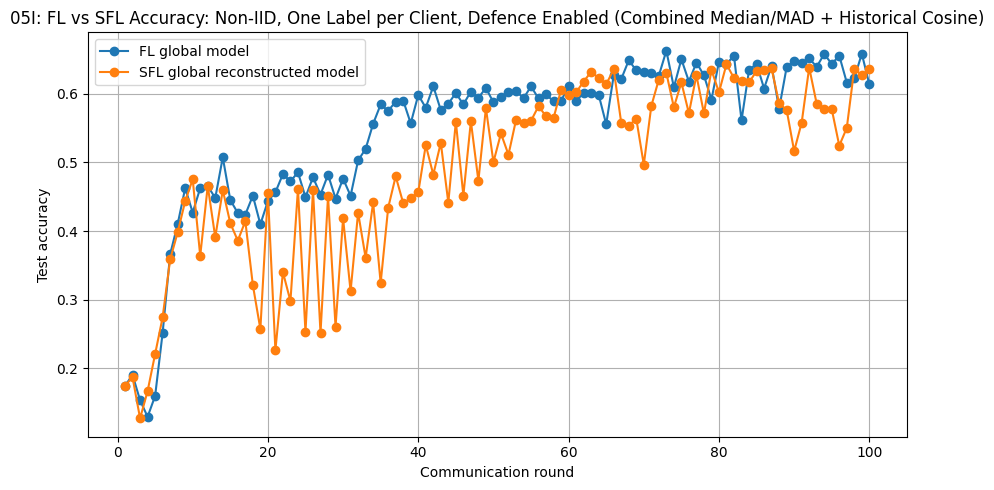

Saved accuracy plot to: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05I_combined_median_cosine/fl_vs_sfl_noniid_one_label_accuracy_100_rounds.png


In [24]:
accuracy_plot_path = os.path.join(PLOTS_DIR, f"fl_vs_sfl_noniid_one_label_accuracy_{ROUNDS}_rounds.png")

plt.figure(figsize=(9, 5))
plt.plot(results_df["round"], results_df["fl_test_accuracy"], marker="o", label="FL global model")
plt.plot(results_df["round"], results_df["sfl_test_accuracy"], marker="o", label="SFL global reconstructed model")
plt.xlabel("Communication round")
plt.ylabel("Test accuracy")
plt.title("05I: FL vs SFL Accuracy: Non-IID, One Label per Client, Defence Enabled (Combined Median/MAD + Historical Cosine)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(accuracy_plot_path, dpi=200)
plt.show()

print("Saved accuracy plot to:", accuracy_plot_path)



## 15. Plot FL vs SFL loss

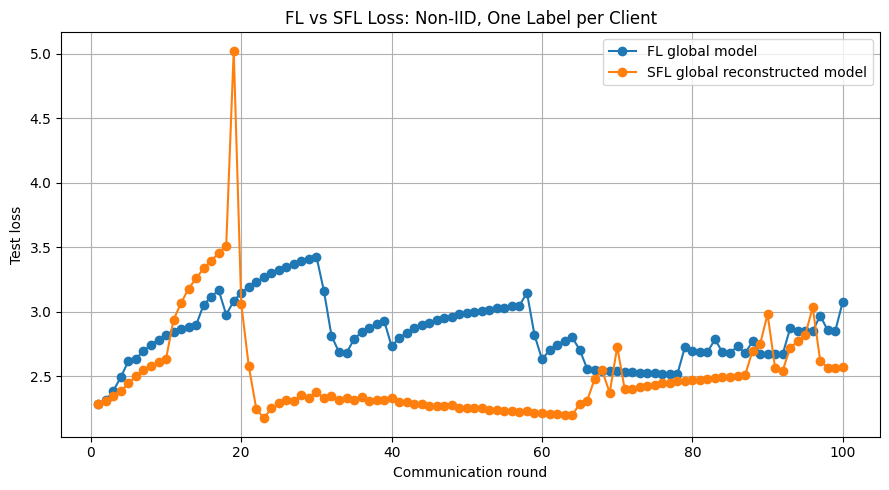

Saved loss plot to: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05I_combined_median_cosine/fl_vs_sfl_noniid_one_label_loss_100_rounds.png


In [25]:
loss_plot_path = os.path.join(PLOTS_DIR, f"fl_vs_sfl_noniid_one_label_loss_{ROUNDS}_rounds.png")

plt.figure(figsize=(9, 5))
plt.plot(results_df["round"], results_df["fl_test_loss"], marker="o", label="FL global model")
plt.plot(results_df["round"], results_df["sfl_test_loss"], marker="o", label="SFL global reconstructed model")
plt.xlabel("Communication round")
plt.ylabel("Test loss")
plt.title("FL vs SFL Loss: Non-IID, One Label per Client")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(loss_plot_path, dpi=200)
plt.show()

print("Saved loss plot to:", loss_plot_path)



## 16. Short report text for README / thesis notes

In [26]:
summary_text = f"""
Experiment: FL vs corrected SFL under extreme non-IID data distribution with realistic SGA poisoning attack and combined Median/MAD + historical cosine defence.

Architecture: 784 -> 512 -> 256 -> 10.
SFL split: client side = 784 -> 512, server side = 512 -> 256 -> 10.
Dataset: MNIST.
Clients: {NUM_CLIENTS}.
Non-IID setting: each client receives data from only one label/class.
Communication rounds: {ROUNDS}.
Local epochs per client per round: {LOCAL_EPOCHS}.
Initial learning rate: {INITIAL_LR}.
Learning-rate decay: {LR_DECAY}.
Attack enabled: {ENABLE_SGA_ATTACK}.
Malicious client ID: {MALICIOUS_CLIENT_ID if ENABLE_SGA_ATTACK else 'none'}.
FL attack: controlled full-model SGA with ATTACK_SCALE_FL={ATTACK_SCALE_FL}.
SFL attack: realistic client-side-only returned-gradient reversal with ATTACK_SCALE_SFL={ATTACK_SCALE_SFL}.
Gradient clipping enabled: {ENABLE_GRAD_CLIPPING}, MAX_GRAD_NORM={MAX_GRAD_NORM}.
Combined defence mode: {COMBINED_DEFENCE_MODE}.
Combined flag mode: {COMBINED_FLAG_MODE}.
MAD multiplier: {DEFENCE_MAD_MULTIPLIER}.
Cosine warm-up starts at round: {DEFENCE_START_ROUND}.

Combined defence logic:
- FL Median/MAD branch: flags abnormal full-model update L2 magnitudes.
- FL cosine branch: flags abnormal full-model update direction changes against each client's own previous-round update.
- SFL Median/MAD branch: flags abnormal server-observable per-client loss values.
- SFL cosine branch: flags abnormal returned-gradient direction changes against each client's own previous-round returned-gradient signature.
- The final flagged-client list is produced using COMBINED_FLAG_MODE={COMBINED_FLAG_MODE}.

Corrected SFL aggregation structure:
- SFL client-side layer(s) are aggregated by a separate client-side FL aggregator.
- SFL server-side layer(s) are aggregated by the SFL server-side aggregator.
- The reconstructed full SFL state is used only for evaluation and FL-vs-SFL comparison; it is not treated as a deployed global model.

The final FL accuracy was {results_df['fl_test_accuracy'].iloc[-1]:.4f}.
The final SFL accuracy was {results_df['sfl_test_accuracy'].iloc[-1]:.4f}.
The final FL NaN flag was {results_df['fl_has_nan'].iloc[-1]} and the final SFL NaN flag was {results_df['sfl_has_nan'].iloc[-1]}.

The saved CSV file contains one row per communication round, including accuracy, loss, attack settings, timing, L2 distance, defence scores, flagged clients, and numerical stability diagnostics.
"""

summary_path = os.path.join(CSV_DIR, f"fl_vs_sfl_noniid_one_label_sga_attack_combined_defence_summary_{ROUNDS}_rounds.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print("Saved summary to:", summary_path)




Experiment: FL vs corrected SFL under extreme non-IID data distribution with realistic SGA poisoning attack and combined Median/MAD + historical cosine defence.

Architecture: 784 -> 512 -> 256 -> 10.
SFL split: client side = 784 -> 512, server side = 512 -> 256 -> 10.
Dataset: MNIST.
Clients: 10.
Non-IID setting: each client receives data from only one label/class.
Communication rounds: 100.
Local epochs per client per round: 1.
Initial learning rate: 0.04.
Learning-rate decay: 0.99.
Attack enabled: True.
Malicious client ID: 0.
FL attack: controlled full-model SGA with ATTACK_SCALE_FL=0.01.
SFL attack: realistic client-side-only returned-gradient reversal with ATTACK_SCALE_SFL=20.0.
Gradient clipping enabled: False, MAX_GRAD_NORM=20.0.
Combined defence mode: median_mad_plus_historical_cosine_warmup.
Combined flag mode: union.
MAD multiplier: 6.0.
Cosine warm-up starts at round: 10.

Combined defence logic:
- FL Median/MAD branch: flags abnormal full-model update L2 magnitudes.
- FL 

## Comparison with the earlier 5-layer and 2-layer notebooks

This version uses a 3-layer fully connected network:

```text
Full FL model: 784 -> 256 -> 128 -> 10
SFL client:    784 -> 256
SFL server:    256 -> 128 -> 10
```

Why this version is useful:

1. **It keeps SFL meaningful**  
   The client has one trainable layer and the server has two trainable layers.

2. **It is still simpler than the 5-layer model**  
   The previous 5-layer MLP was very unstable under one-label-per-client non-IID training.

3. **It gives more server-side depth than the 2-layer model**  
   The earlier 2-layer model had only one server-side layer. This version gives the server a deeper role while remaining easier to train than the 5-layer model.

4. **It keeps FL/SFL architecture aligned**  
   The FL-only clients train the same complete 3-layer model that is reconstructed from the SFL client and server states.

Recommended next checks:

- Watch whether the L2 distance remains close to zero.
- Compare the accuracy curve against the 2-layer and 5-layer versions.
- If accuracy collapses again, reduce `INITIAL_LR` from `0.01` to `0.005` before adding any stabilization tricks.
